In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
import math

# from RRAM import *
# from RRAM import Montecarlo as mc
# from RRAM import Plot_PostProcess as pplt

In [14]:
def Plot_panel(data_path: str):
    """
    data_path: contiene la ruta del archivo de datos, se encuentra en la primera columna la variable independiente
               y en las siguientes columnas las variables dependientes
    """

    # leo los datos desde el csv
    data = pd.read_csv(data_path)

    # Elimino la primera fila que son los nombres de las columnas
    data = data.values[1:, :]

    # Extraigo la variable independiente
    x = data[:, 0]

    # Extraigo las variables dependientes
    y = data[:, 1:]

    # Creo la figura que será un panel con 4 subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

    # Creo el primer subplot
    ax1.plot(x, y[:, 0])
    ax1.set_title('Velocidad')

    # Creo el segundo subplot
    ax2.plot(x, y[:, 1])
    ax2.set_title('desplazamiento')

    # Creo el tercer subplot
    ax3.plot(x, y[:, 2])
    ax3.set_title('Probabilidad generacion')

    # Creo el tercer subplot
    ax4.plot(x, y[:, 3])
    ax4.set_title('Probabilidad de destruccion')

    # Ajustamos el espacio entre los plots
    fig.tight_layout()

    # Represento todos los subplots
    plt.show()

    return None

In [15]:
# def RepresentateALLState(state_matrix: np.ndarray, oxygen_matrix: np.ndarray, fig, ax, filename: str = "grafica.png") -> None:
#     """
#     Representates the state and oxygen matrices using a custom colormap and saves the plot as an image.

#     Parameters:
#     - state_matrix (np.ndarray): The state matrix to be represented.
#     - oxygen_matrix (np.ndarray): The oxygen matrix to be represented.
#     - fig: The figure object to plot on.
#     - ax: The axes object to plot on.
#     - filename (str): The name of the output image file (default: "grafica.png").

#     Returns:
#     None
#     """

#     # Create a custom color map for the first matrix
#     colors1 = [
#         (1, 1, 1),                 # Color for value 0 (white)
#         (0.478, 0.627, 0.870),     # Color for value 1 (blue)
#     ]

#     # Create a custom color map for the second matrix
#     colors2 = [
#         (1, 1, 1),                 # Color for value 0 (white)
#         (0.870, 0.478, 0.627),     # Color for value 1 (red)
#     ]

#     cmap1 = LinearSegmentedColormap.from_list("cmap1", colors1, N=2)
#     cmap2 = LinearSegmentedColormap.from_list("cmap2", colors2, N=2)

#     # Use imshow to represent the configuration matrix
#     ax.imshow(state_matrix, cmap=cmap1, origin='upper', alpha=0.85)

#     # Use imshow to represent the oxygen matrix
#     ax.imshow(oxygen_matrix, cmap=cmap2, origin='upper', alpha=0.45)

#     # Set the aspect ratio to make cells square
#     ax.set_aspect('equal')

#     # Set the x-axis labels at the top
#     # ax.xaxis.tick_top()

#     # plt.title("Iteration {}".format(filename.split("_")[1].split(".")[0]))

#     # Close the figure and save it to a file
#     plt.savefig(filename)
#     plt.close(fig)

#     return None

In [16]:
# # Cargo el fichero con las configuraciones
# with open('Results/Configurations_0.pkl', 'rb') as f:
#     state_matrix = pickle.load(f)

#     # Cargo el fichero con las configuraciones
# with open('Results/Oxygen_0.pkl', 'rb') as f:
# oxygen_matrix = pickle.load(f)

# RepresentateALLState(state_matrix[4500], oxygen_matrix[4500], plt.figure(), plt.gca(), "grafica.png")

In [17]:
num_pasos = 10
total_simulation_time = 10
atom_size = 0.25e-9
temperature = 300
k_b_ev = 8.617333262145e-5
gamma_drift = 8  # *k_b_ev*temperature
E_m = 1.0
t_0 = 1e13

In [18]:
tiempo_simulacion = np.linspace(0, total_simulation_time, num_pasos+1)
E_field = np.linspace(0, 3/(10e-9), num_pasos+1)
paso_temporal = total_simulation_time / num_pasos

In [19]:
senoh = np.sinh((atom_size * E_field * gamma_drift) / (2 * k_b_ev * temperature))
exp_velocity = math.exp(-E_m / (k_b_ev * temperature))
velocidad = 2 * t_0 * atom_size * senoh * exp_velocity

desplazamiento = np.int64(np.round((velocidad * paso_temporal) / atom_size))

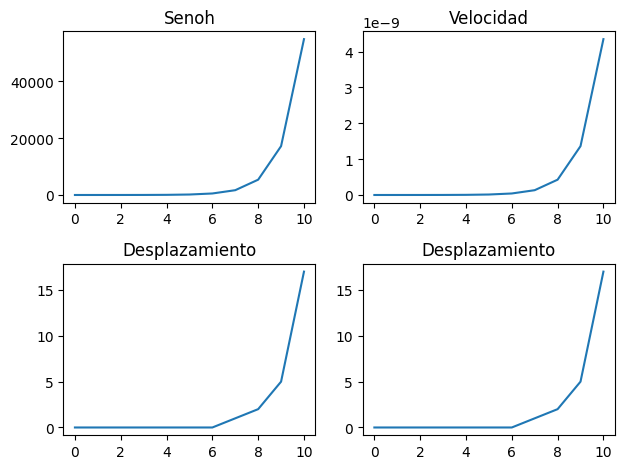

In [20]:
# Creo la figura que será un panel con 4 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

# Creo el primer subplot
ax1.plot(tiempo_simulacion, senoh)
ax1.set_title('Senoh')

# Creo el segundo subplot
ax2.plot(tiempo_simulacion, velocidad)
ax2.set_title('Velocidad')

# Creo el tercer subplot
ax3.plot(tiempo_simulacion, desplazamiento)
ax3.set_title('Desplazamiento')

# Creo el tercer subplot
ax4.plot(tiempo_simulacion, desplazamiento)
ax4.set_title('Desplazamiento')

# Ajustamos el espacio entre los plots
fig.tight_layout()

# Represento todos los subplots
plt.show()

In [21]:
atom_size = np.linspace(0.15e-9, 0.24e-9, 10)

atom_size

array([1.5e-10, 1.6e-10, 1.7e-10, 1.8e-10, 1.9e-10, 2.0e-10, 2.1e-10,
       2.2e-10, 2.3e-10, 2.4e-10])